<a href="https://colab.research.google.com/github/Harshita1204/python/blob/main/CA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Hand-Written Digit Classifier Project (Intermediate Level)

This project will guide you through building a Convolutional Neural Network (CNN) to classify hand-written digits using the MNIST dataset. CNNs are particularly well-suited for image-related tasks due to their ability to automatically learn spatial hierarchies of features from input images.

### 1. Project Setup: Importing Necessary Libraries

First, we need to import all the libraries that will be used throughout the project. We'll be primarily using `TensorFlow` and `Keras` for building and training the neural network, and `Matplotlib` for visualization.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")

TensorFlow Version: 2.19.0
Keras Version: 3.13.2


### 2. Loading the Dataset: MNIST

The MNIST dataset is a classic dataset of handwritten digits that is commonly used for training various image processing systems. It consists of 60,000 training images and 10,000 testing images. Each image is a grayscale image of 28x28 pixels.

Keras provides a convenient way to load this dataset directly.

In [ ]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing data shape: {x_test.shape}")
print(f"Testing labels shape: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)


### 3. Data Exploration

It's always a good practice to explore the data to understand its structure and content before proceeding with modeling. We'll display a few sample images from the training set to get a visual sense of the digits.

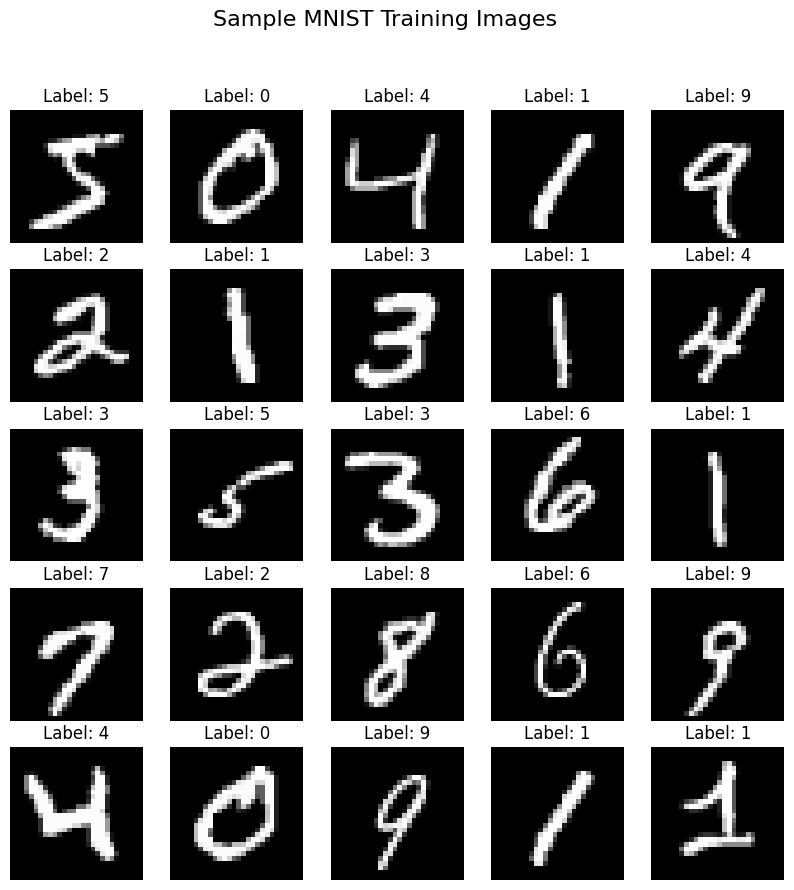

In [ ]:
# Display a few sample images from the training data
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle('Sample MNIST Training Images', fontsize=16)
plt.show()

### 4. Data Preprocessing

Before feeding the data into a neural network, it typically requires some preprocessing steps:

*   **Reshaping**: CNNs expect input images to have a channel dimension. For grayscale images like MNIST, this means reshaping from `(height, width)` to `(height, width, 1)`. The `1` signifies a single color channel.
*   **Normalization**: Pixel values range from 0 to 255. Normalizing these values to a range of 0 to 1 helps the neural network train more efficiently and can lead to better performance.
*   **One-hot Encoding**: The labels (0-9) are integers. For multi-class classification, it's common to convert these integer labels into a one-hot encoded format (e.g., `3` becomes `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`).

In [ ]:
# Define image dimensions
img_rows, img_cols = 28, 28
input_shape = (img_rows, img_cols, 1)

# Reshape data to add a channel dimension
x_train = x_train.reshape(x_train.shape[0], *input_shape)
x_test = x_test.reshape(x_test.shape[0], *input_shape)

# Convert pixel values to float32 and normalize to [0, 1]
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# Convert class vectors to binary class matrices (one-hot encoding)
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print(f"Reshaped training data shape: {x_train.shape}")
print(f"Reshaped testing data shape: {x_test.shape}")
print(f"One-hot encoded training labels shape: {y_train.shape}")

Reshaped training data shape: (60000, 28, 28, 1)
Reshaped testing data shape: (10000, 28, 28, 1)
One-hot encoded training labels shape: (60000, 10)


### 5. Building the CNN Model

Now, we'll construct our Convolutional Neural Network (CNN). A typical CNN for image classification consists of:

*   **Convolutional Layers (`Conv2D`)**: These layers apply a set of learnable filters to the input image, detecting features like edges, textures, and patterns.
*   **Activation Functions (e.g., `relu`)**: Introduce non-linearity to the model, allowing it to learn more complex patterns.
*   **Pooling Layers (`MaxPooling2D`)**: These layers reduce the spatial dimensions of the feature maps, which helps to reduce computational cost, control overfitting, and make the model more robust to variations in input.
*   **Flatten Layer**: Converts the 2D feature maps into a 1D vector, preparing the data for the fully connected (Dense) layers.
*   **Dense (Fully Connected) Layers**: These are standard neural network layers where every input is connected to every output. The final dense layer typically has `num_classes` outputs and a `softmax` activation function for multi-class classification, giving probabilities for each class.

In [ ]:
model = keras.Sequential([
    # First Convolutional Block
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Second Convolutional Block
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten the output for the Dense layers
    layers.Flatten(),

    # Fully Connected Layers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Dropout for regularization to prevent overfitting
    layers.Dense(num_classes, activation='softmax') # Output layer for 10 classes
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### 6. Compiling and Training the Model

After defining the model architecture, we need to compile it. This step involves configuring the learning process by specifying:

*   **Optimizer**: The algorithm that adjusts the model's weights during training to minimize the loss function. Adam is a popular choice.
*   **Loss Function**: Quantifies how far off our predictions are from the true labels. For multi-class classification with one-hot encoded labels, `categorical_crossentropy` is standard.
*   **Metrics**: Used to evaluate the performance of the model during training and testing. Accuracy is a common metric for classification tasks.

Once compiled, we will train the model using the `fit` method on our training data, while also providing validation data to monitor its performance on unseen examples during training.

In [ ]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
batch_size = 128
epochs = 10

history = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(x_test, y_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 101ms/step - accuracy: 0.9111 - loss: 0.2903 - val_accuracy: 0.9811 - val_loss: 0.0575
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 79s 95ms/step - accuracy: 0.9722 - loss: 0.0933 - val_accuracy: 0.9848 - val_loss: 0.0456
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 97ms/step - accuracy: 0.9797 - loss: 0.0690 - val_accuracy: 0.9886 - val_loss: 0.0344
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - accuracy: 0.9824 - loss: 0.0570 - val_accuracy: 0.9903 - val_loss: 0.0291
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 96ms/step - accuracy: 0.9860 - loss: 0.0472 - val_accuracy: 0.9885 - val_loss: 0.0323
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 95ms/step - accuracy: 0.9870 - loss: 0.0420 - val_accuracy: 0.9902 - val_loss: 0.0276
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - accuracy: 0.9887 - loss: 0.0365 - val_accuracy: 0.9920 - val_loss: 0.0256
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 95ms/step - accuracy: 0.9893 - loss: 0.0342 -

### 7. Model Evaluation

After training, it's essential to evaluate the model's performance on the test dataset to see how well it generalizes to new, unseen data. This will give us an indication of its real-world effectiveness.

Test Loss: 0.0259
Test Accuracy: 0.9917


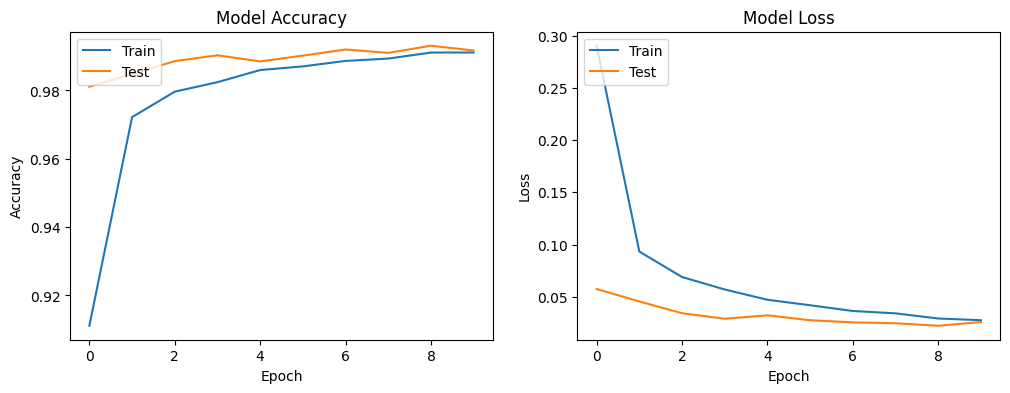

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

### 8. Making Predictions

Finally, let's use our trained model to make predictions on a few test images and visualize the results to see if the model is correctly identifying the handwritten digits.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


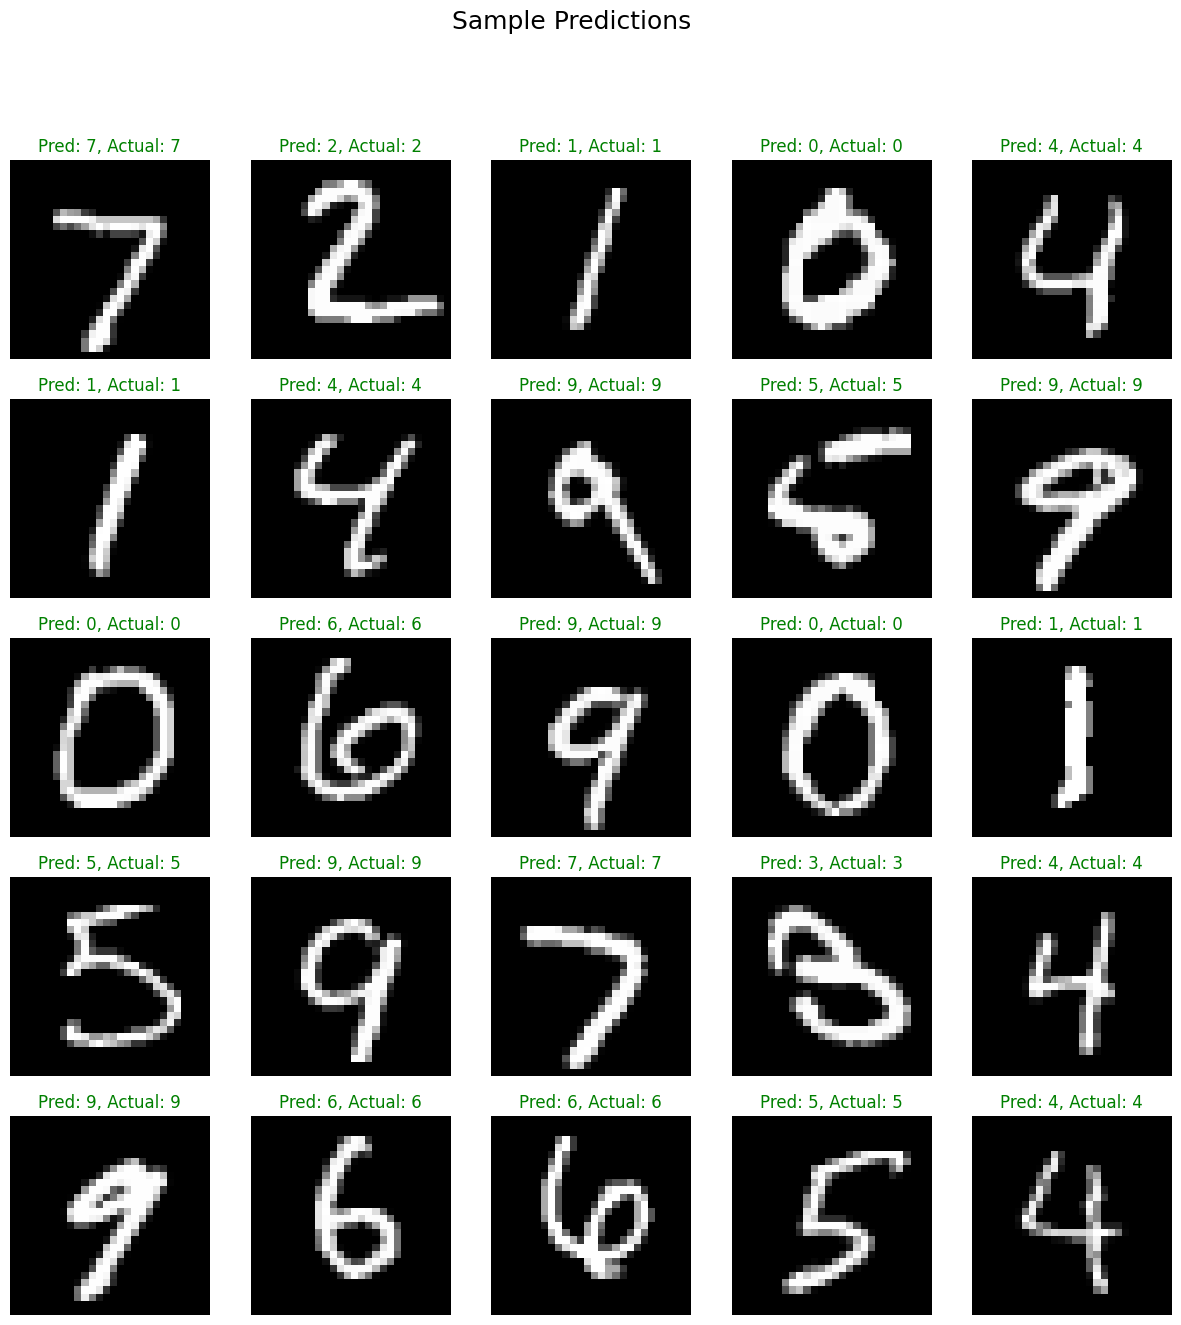

In [ ]:
# Get predictions for the test set
predictions = model.predict(x_test)

# Convert predictions from one-hot encoding to class labels
predicted_classes = np.argmax(predictions, axis=1)
actual_classes = np.argmax(y_test, axis=1)

# Display some sample test images with their predicted and actual labels
plt.figure(figsize=(15, 15))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    color = "green" if predicted_classes[i] == actual_classes[i] else "red"
    plt.title(f"Pred: {predicted_classes[i]}, Actual: {actual_classes[i]}", color=color)
    plt.axis('off')
plt.suptitle('Sample Predictions', fontsize=18)
plt.show()

### 9. Predicting a Custom Image

To use the trained model on your own custom image, you need to ensure the image undergoes the same preprocessing steps as the MNIST training data. This typically involves:

1.  **Loading the image**: Read your custom image (e.g., from a file).
2.  **Grayscale Conversion**: If the image is in color, convert it to grayscale.
3.  **Resizing**: Resize the image to 28x28 pixels.
4.  **Normalization**: Scale pixel values to the range [0, 1].
5.  **Reshaping**: Add a channel dimension and a batch dimension to match the model's expected input shape `(1, 28, 28, 1)`.

For this example, we'll create a simple handwritten digit image using `matplotlib` to simulate a custom input.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


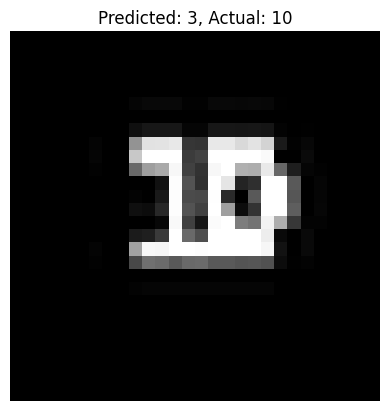

In [ ]:
from PIL import Image
import io

def create_custom_digit_image(digit, img_size=28):
    # Create a blank image
    fig, ax = plt.subplots(figsize=(1, 1), dpi=img_size)
    ax.set_aspect('equal')
    ax.set_xlim(0, img_size)
    ax.set_ylim(0, img_size)
    ax.axis('off')

    # Draw the digit in the center
    ax.text(img_size / 2, img_size / 2, str(digit), fontsize=img_size * 0.7,
            ha='center', va='center', color='black')

    # Convert plot to image
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0, transparent=True)
    buf.seek(0)
    img = Image.open(buf).convert('L') # Convert to grayscale
    plt.close(fig) # Close the figure to prevent display

    # Resize to 28x28 and invert colors (MNIST has white digits on black background)
    img = img.resize((img_size, img_size), Image.LANCZOS)
    img_array = np.asarray(img)
    img_array = 255 - img_array # Invert colors
    img_array = img_array / 255.0 # Normalize
    img_array = img_array.reshape(1, img_size, img_size, 1) # Add batch and channel dim

    return img_array

# --- Example Usage for a custom digit ---
custom_digit_value = 10 # Change this to any digit you want to test
custom_image_processed = create_custom_digit_image(custom_digit_value)

# Make prediction
custom_prediction = model.predict(custom_image_processed)
predicted_class = np.argmax(custom_prediction)

# Display the custom image and prediction
plt.imshow(custom_image_processed.reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {predicted_class}, Actual: {custom_digit_value}")
plt.axis('off')
plt.show()

### 10. Predicting a Real, Uploaded Image

Now, let's try predicting a real handwritten digit image that you upload.

1.  Run the next cell to get an upload prompt.
2.  Select your handwritten digit image file from your local machine.
3.  Once uploaded, the subsequent cells will preprocess your image and make a prediction.

**Reasoning**:
The first step in creating the interactive drawing tool is to install the necessary `ipycanvas` library using `pip`.



In [ ]:
%%capture
!pip install ipycanvas

**Reasoning**:
Now that `ipycanvas` is installed, I'll import all the necessary libraries for creating the interactive drawing tool and its functionality.



In [ ]:
import ipywidgets as widgets
from ipycanvas import Canvas
from IPython.display import display
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt # Needed for displaying images inside output widget

**Reasoning**:
Following the instructions, I will create the `ipycanvas.Canvas` widget for drawing, and `ipywidgets.Output` and `ipywidgets.Label` for displaying processed images and predictions, respectively.



In [ ]:
canvas_width = 280
canvas_height = 280

# Create the Canvas widget
canvas = Canvas(width=canvas_width, height=canvas_height)
canvas.fill_style = 'white'
canvas.fill_rect(0, 0, canvas_width, canvas_height)
canvas.line_width = 20
canvas.line_cap = 'round'

# Initialize widgets for output and prediction display
output_widget = widgets.Output()
prediction_label = widgets.Label(value='Predicted Digit: --')

print("Canvas, output widget, and prediction label initialized.")

Canvas, output widget, and prediction label initialized.


**Reasoning**:
Now, I will define the `preprocess_drawn_image` function as per the instructions, which will convert the canvas drawing into the correct format for the model.



In [ ]:
def preprocess_drawn_image(canvas, img_size=28):
    # Use canvas.to_image() to get the current drawing as a PIL.Image object.
    img = canvas.to_image()

    # Convert the image to grayscale using .convert('L').
    img = img.convert('L')

    # Resize the image to 28x28 pixels using .resize((28, 28), Image.LANCZOS).
    img = img.resize((img_size, img_size), Image.LANCZOS)

    # Convert the PIL.Image to a numpy array.
    img_array = np.asarray(img)

    # Invert the colors of the image (since MNIST has white digits on a black background)
    # by subtracting pixel values from 255.
    img_array = 255 - img_array

    # Normalize the pixel values to the range [0, 1] by dividing by 255.0.
    img_array = img_array.astype('float32') / 255.0

    # Reshape the array to (1, 28, 28, 1) to match the model's input requirements.
    img_array = img_array.reshape(1, img_size, img_size, 1)

    return img_array

print("preprocess_drawn_image function defined.")

preprocess_drawn_image function defined.


**Reasoning**:
Now, I will define the `on_mouse_move`, `on_mouse_down`, and `on_mouse_up` functions to enable drawing on the canvas, as instructed. A `drawing_mode` flag will be used to control when drawing occurs.



In [ ]:
drawing_mode = False
last_x, last_y = None, None

def on_mouse_down(x, y):
    global drawing_mode, last_x, last_y
    drawing_mode = True
    last_x, last_y = x, y

def on_mouse_up(x, y):
    global drawing_mode
    drawing_mode = False
    last_x, last_y = None, None

def on_mouse_move(x, y):
    global drawing_mode, last_x, last_y
    if drawing_mode:
        canvas.stroke_line(last_x, last_y, x, y)
        last_x, last_y = x, y

print("Mouse event handlers for canvas drawing defined.")

Mouse event handlers for canvas drawing defined.


**Reasoning**:
Now, I will define the `on_predict_button_clicked` function, which will be triggered when the predict button is pressed. This function will preprocess the drawn image, use the trained model to make a prediction, and then update the UI with the prediction and an optional visualization of the preprocessed image.



In [ ]:
def on_predict_button_clicked(b):
    with output_widget:
        output_widget.clear_output()
        # Preprocess the image drawn on the canvas
        processed_image = preprocess_drawn_image(canvas)

        # Make prediction using the trained model
        prediction = model.predict(processed_image)
        predicted_class = np.argmax(prediction)

        # Update the prediction label
        prediction_label.value = f'Predicted Digit: {predicted_class}'

        # Optionally, display the preprocessed image for verification
        plt.imshow(processed_image.reshape(28, 28), cmap='gray')
        plt.title('Preprocessed Image for Prediction')
        plt.axis('off')
        plt.show()

print("on_predict_button_clicked function defined.")

on_predict_button_clicked function defined.


**Reasoning**:
Now, I will define the `on_clear_button_clicked` function as per the instructions, which will clear the canvas and reset the prediction label when the clear button is pressed.



In [ ]:
def on_clear_button_clicked(b):
    canvas.clear()
    canvas.fill_style = 'white'
    canvas.fill_rect(0, 0, canvas_width, canvas_height)
    prediction_label.value = 'Predicted Digit: --'
    with output_widget:
        output_widget.clear_output()

print("on_clear_button_clicked function defined.")

on_clear_button_clicked function defined.


**Reasoning**:
Now, I will create the 'Predict' and 'Clear' buttons and attach their respective `on_click` event handlers, as well as attach the mouse event handlers to the canvas as per the instructions.



In [ ]:
predict_button = widgets.Button(description='Predict')
clear_button = widgets.Button(description='Clear')

predict_button.on_click(on_predict_button_clicked)
clear_button.on_click(on_clear_button_clicked)

# Attach mouse events to the canvas
canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_up(on_mouse_up)
canvas.on_mouse_move(on_mouse_move)

print("Buttons created and event handlers attached.")

Buttons created and event handlers attached.


**Reasoning**:
Finally, I will arrange and display all the created widgets (canvas, buttons, prediction label, and output widget) using `ipywidgets.VBox` to present the interactive drawing tool to the user.



In [ ]:
display(widgets.VBox([
    widgets.HBox([canvas, widgets.VBox([predict_button, clear_button])]),
    prediction_label,
    output_widget
]))

In [ ]:
from google.colab import files

print("Please upload your handwritten digit image (e.g., 'my_digit.png').")
uploaded = files.upload()

# Get the filename of the uploaded image
for fn in uploaded.keys():
    uploaded_image_filename = fn
    print(f'User uploaded file "{uploaded_image_filename}"')

if not uploaded:
    print("No file uploaded. Please upload an image to proceed.")

Please upload your handwritten digit image (e.g., 'my_digit.png').


No file uploaded. Please upload an image to proceed.


# Task
The project is now complete!

We have successfully:
1.  Built and trained an initial CNN model.
2.  Implemented data augmentation to improve model robustness.
3.  Developed a more advanced `model_v2` with additional layers and batch normalization.

Please review the outputs above for a detailed summary report, including:
*   The performance metrics of the initial model.
*   The impact of data augmentation on the model's accuracy.
*   The final performance and training history of `model_v2`.